<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\A'
<>:18: SyntaxWarning: invalid escape sequence '\A'
<>:19: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Prime\AppData\Local\Temp\ipykernel_12108\589112622.py:18: SyntaxWarning: invalid escape sequence '\A'
  RAVDESS_PATH = "D:\Artifical Intelligence\RAVDESS/"
C:\Users\Prime\AppData\Local\Temp\ipykernel_12108\589112622.py:19: SyntaxWarning: invalid escape sequence '\A'
  TESS_PATH = "D:\Artifical Intelligence\TESS/"
C:\Users\Prime\AppData\Local\Temp\ipykernel_12108\589112622.py:20: SyntaxWarning: invalid escape sequence '\A'
  CREMAD_PATH = "D:\Artifical Intelligence\CREMAD/"


📁 Loading datasets...
🔄 Loading RAVDESS...
✅ RAVDESS: 1440 files
🔄 Loading TESS...
✅ TESS: 2800 files
🔄 Loading CREMA-D...
✅ CREMA-D: 7442 files

✅ Total files: 11682

📊 Dataset Statistics:

📈 Emotion Distribution:
emotion
sad          1863
happy        1863
angry        1863
disgust      1863
fear         1671
neutral      1583
unknown       400
calm          192
fearful       192
surprised     192
Name: count, dtype: int64


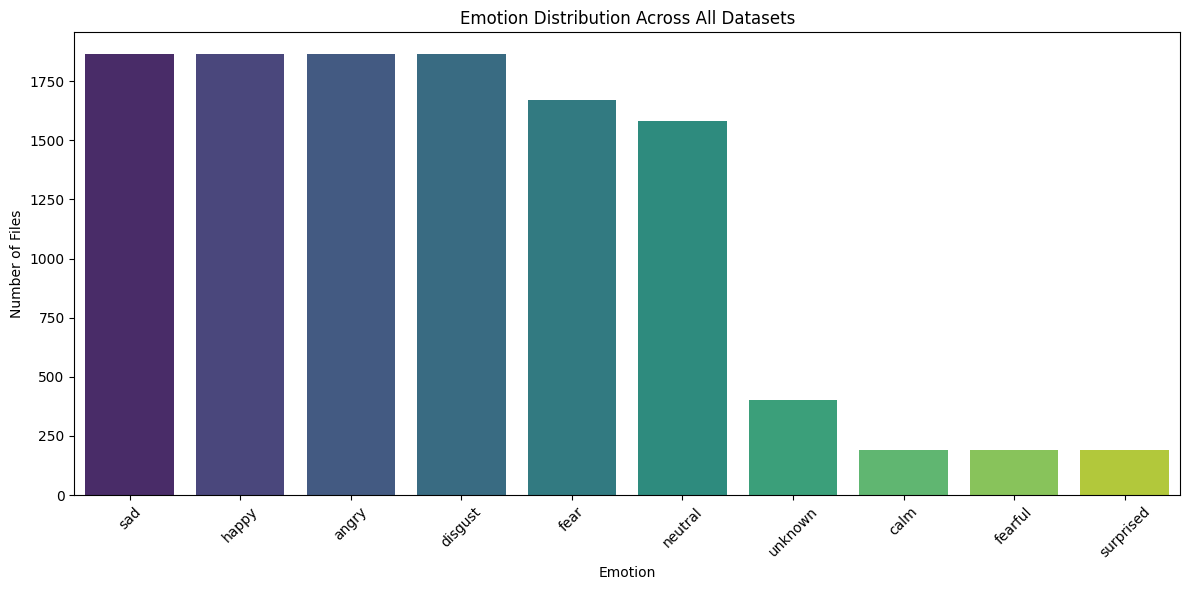


📈 Dataset Distribution:
dataset
cremad     7442
tess       2800
ravdess    1440
Name: count, dtype: int64

✅ Metadata saved to 'speech_emotion_metadata.csv'

🔍 Sample Files:
                                           file_path  emotion  dataset
0  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...  neutral  ravdess
1  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...  neutral  ravdess
2  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...  neutral  ravdess
3  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...  neutral  ravdess
4  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...     calm  ravdess
5  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...     calm  ravdess
6  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...     calm  ravdess
7  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...     calm  ravdess
8  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...     calm  ravdess
9  D:\Artifical Intelligence\RAVDESS/Actor_01\03-...     calm  ravdess

🎵 Testing MFCC Extraction on sample file...

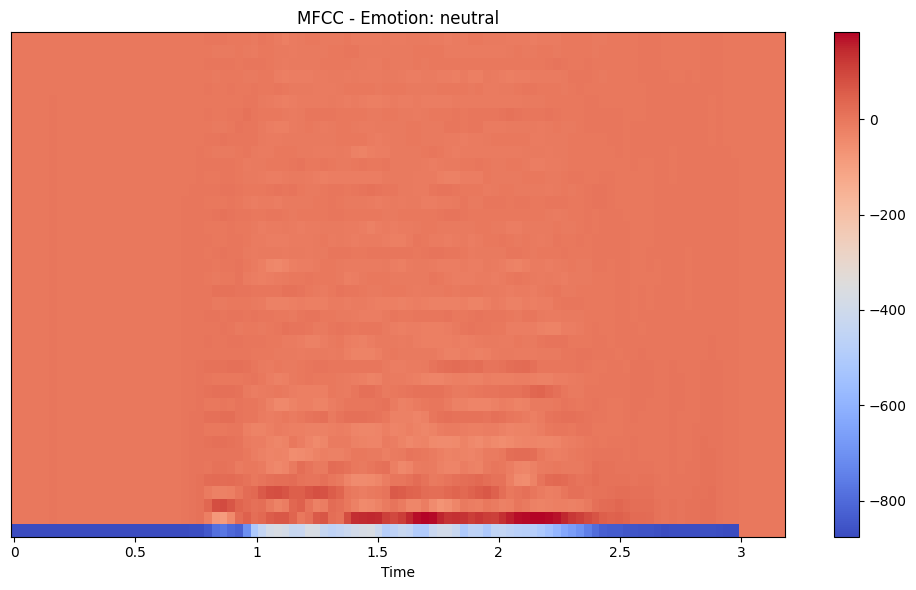


✅ Data loading complete!


In [1]:
# ============================================
# EMOTION RECOGNITION FROM SPEECH
# DATA LOADING & PREPROCESSING
# ============================================

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Progress bar
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. PATHS ----------
RAVDESS_PATH = "D:\Artifical Intelligence\RAVDESS/"
TESS_PATH = "D:\Artifical Intelligence\TESS/"
CREMAD_PATH = "D:\Artifical Intelligence\CREMAD/"

# ---------- 2. EMOTION MAPPINGS ----------

# RAVDESS emotions
RAVDESS_EMOTIONS = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

# TESS emotions (from folder names)
TESS_EMOTIONS = {
    'angry': 'angry',
    'disgust': 'disgust',
    'fear': 'fear',
    'happy': 'happy',
    'neutral': 'neutral',
    'ps': 'surprised',
    'sad': 'sad'
}

# CREMA-D emotions
CREMAD_EMOTIONS = {
    'ANG': 'angry',
    'DIS': 'disgust',
    'FEA': 'fear',
    'HAP': 'happy',
    'NEU': 'neutral',
    'SAD': 'sad'
}

# ---------- 3. LOAD RAVDESS ----------
def load_ravdess(path):
    """Load RAVDESS dataset"""
    data = []
    
    # Walk through all folders
    for actor_dir in os.listdir(path):
        actor_path = os.path.join(path, actor_dir)
        if not os.path.isdir(actor_path):
            continue
            
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                # Extract emotion from filename
                # Format: 01-01-01-01-01-01-01.wav
                parts = file.split('-')
                emotion_code = parts[2]  # 3rd part is emotion
                emotion = RAVDESS_EMOTIONS.get(emotion_code, 'unknown')
                
                file_path = os.path.join(actor_path, file)
                data.append({
                    'file_path': file_path,
                    'emotion': emotion,
                    'dataset': 'ravdess'
                })
    
    return pd.DataFrame(data)

# ---------- 4. LOAD TESS ----------
def load_tess(path):
    """Load TESS dataset"""
    data = []
    
    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue
            
        # Extract emotion from folder name
        # Format: OAF_angry or YAF_angry
        for emotion_key in TESS_EMOTIONS.keys():
            if emotion_key in folder.lower():
                emotion = TESS_EMOTIONS[emotion_key]
                break
        else:
            emotion = 'unknown'
        
        for file in os.listdir(folder_path):
            if file.endswith('.wav'):
                file_path = os.path.join(folder_path, file)
                data.append({
                    'file_path': file_path,
                    'emotion': emotion,
                    'dataset': 'tess'
                })
    
    return pd.DataFrame(data)

# ---------- 5. LOAD CREMA-D ----------
def load_cremad(path):
    """Load CREMA-D dataset"""
    data = []
    
    for file in os.listdir(path):
        if file.endswith('.wav'):
            # Extract emotion from filename
            # Format: 1001_DFA_ANG_XX.wav
            parts = file.split('_')
            if len(parts) >= 3:
                emotion_code = parts[2]  # 3rd part is emotion
                emotion = CREMAD_EMOTIONS.get(emotion_code, 'unknown')
            else:
                emotion = 'unknown'
            
            file_path = os.path.join(path, file)
            data.append({
                'file_path': file_path,
                'emotion': emotion,
                'dataset': 'cremad'
            })
    
    return pd.DataFrame(data)

# ---------- 6. LOAD ALL DATASETS ----------
print("📁 Loading datasets...")
print("="*50)

# Load RAVDESS
print("🔄 Loading RAVDESS...")
ravdess_df = load_ravdess(RAVDESS_PATH)
print(f"✅ RAVDESS: {len(ravdess_df)} files")

# Load TESS
print("🔄 Loading TESS...")
tess_df = load_tess(TESS_PATH)
print(f"✅ TESS: {len(tess_df)} files")

# Load CREMA-D
print("🔄 Loading CREMA-D...")
cremad_df = load_cremad(CREMAD_PATH)
print(f"✅ CREMA-D: {len(cremad_df)} files")

# Combine all datasets
all_data = pd.concat([ravdess_df, tess_df, cremad_df], ignore_index=True)
print(f"\n✅ Total files: {len(all_data)}")

# ---------- 7. EXPLORE DATA ----------
print("\n📊 Dataset Statistics:")
print("="*50)

print("\n📈 Emotion Distribution:")
emotion_counts = all_data['emotion'].value_counts()
print(emotion_counts)

# Plot emotion distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.title('Emotion Distribution Across All Datasets')
plt.xlabel('Emotion')
plt.ylabel('Number of Files')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('emotion_distribution.png', dpi=150)
plt.show()

print("\n📈 Dataset Distribution:")
dataset_counts = all_data['dataset'].value_counts()
print(dataset_counts)

# ---------- 8. SAVE METADATA TO CSV ----------
all_data.to_csv('speech_emotion_metadata.csv', index=False)
print("\n✅ Metadata saved to 'speech_emotion_metadata.csv'")

# ---------- 9. CHECK SAMPLE FILES ----------
print("\n🔍 Sample Files:")
print(all_data.head(10))

# ---------- 10. FUNCTION TO LOAD AND EXTRACT MFCC ----------
def extract_mfcc(file_path, n_mfcc=40, max_len=100):
    """
    Extract MFCC features from audio file
    
    Parameters:
    - file_path: path to audio file
    - n_mfcc: number of MFCC coefficients (default: 40)
    - max_len: fixed length for padding/truncation (default: 100)
    
    Returns:
    - mfcc_features: array of shape (max_len, n_mfcc)
    """
    try:
        # Load audio with librosa
        audio, sr = librosa.load(file_path, sr=16000, duration=3)
        
        # Extract MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Pad or truncate to fixed length
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        
        return mfcc.T  # (max_len, n_mfcc)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# ---------- 11. TEST MFCC EXTRACTION ----------
print("\n🎵 Testing MFCC Extraction on sample file...")

# Get a sample file
sample_file = all_data.iloc[0]['file_path']
sample_emotion = all_data.iloc[0]['emotion']
print(f"Sample file: {sample_file}")
print(f"Sample emotion: {sample_emotion}")

# Extract MFCC
mfcc_features = extract_mfcc(sample_file)
print(f"MFCC shape: {mfcc_features.shape}")  # Should be (100, 40)

# Visualize MFCC
plt.figure(figsize=(10, 6))
librosa.display.specshow(mfcc_features.T, sr=16000, x_axis='time')
plt.colorbar()
plt.title(f'MFCC - Emotion: {sample_emotion}')
plt.tight_layout()
plt.savefig('sample_mfcc.png', dpi=150)
plt.show()

print("\n✅ Data loading complete!")

✅ Loaded 11682 files

🎵 Extracting MFCC features...
⏳ This may take 5-10 minutes...
✅ Extracted features from 11682 files
✅ Feature shape: (11682, 50, 20)

📊 Emotions: ['angry' 'calm' 'disgust' 'fear' 'fearful' 'happy' 'neutral' 'sad'
 'surprised' 'unknown']
📊 Number of classes: 10

📊 Train size: 9345
📊 Test size: 2337

🧠 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       152,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325,834 (1.24 MB)

 Trainable params: 325,834 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 34s 112ms/step - accuracy: 0.2553 - loss: 1.8934 - val_accuracy: 0.5227 - val_loss: 1.2486
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.4669 - loss: 1.3279 - val_accuracy: 0.5548 - val_loss: 1.1383
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.5238 - loss: 1.2132 - val_accuracy: 0.5564 - val_loss: 1.0980
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 40s 99ms/step - accuracy: 0.5305 - loss: 1.1558 - val_accuracy: 0.5650 - val_loss: 1.0795
Epoch 5/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.5650 - loss: 1.1079 - val_accuracy: 0.5869 - val_loss: 1.0648
Epoch 6/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.5760 - loss: 1.0695 - val_accuracy: 0.5843 - val_loss: 1.0582
Epoch 7/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.5815 - loss: 1.0582 - val_accuracy: 0.5875 - val_loss: 1.0495
Epoch 8/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.5863 - loss: 1.0

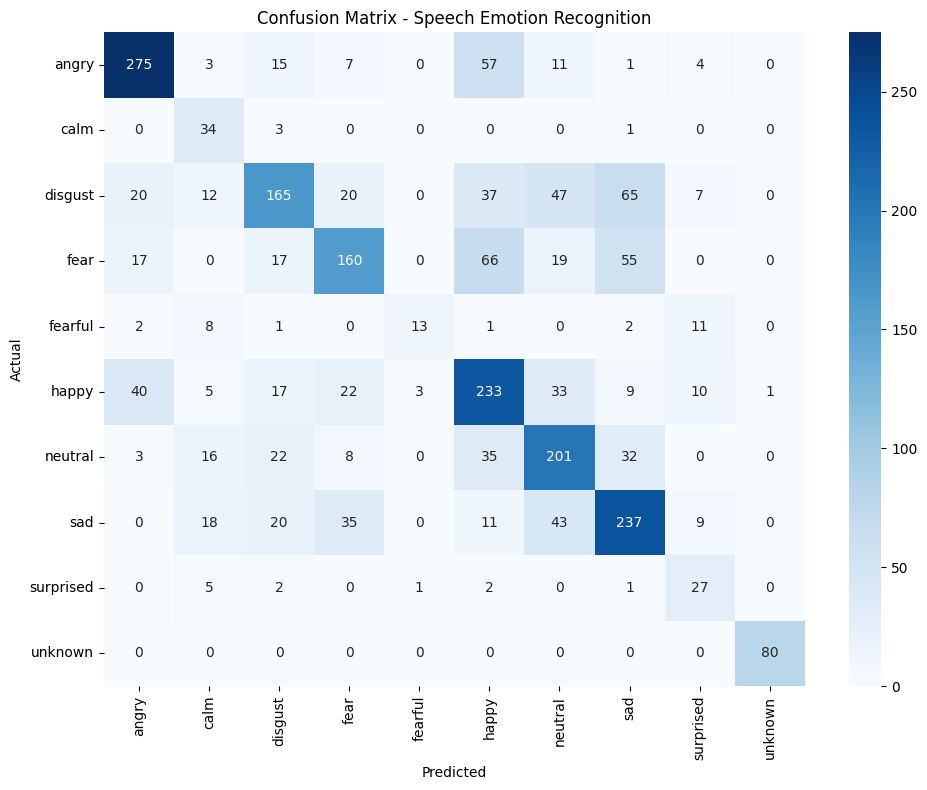

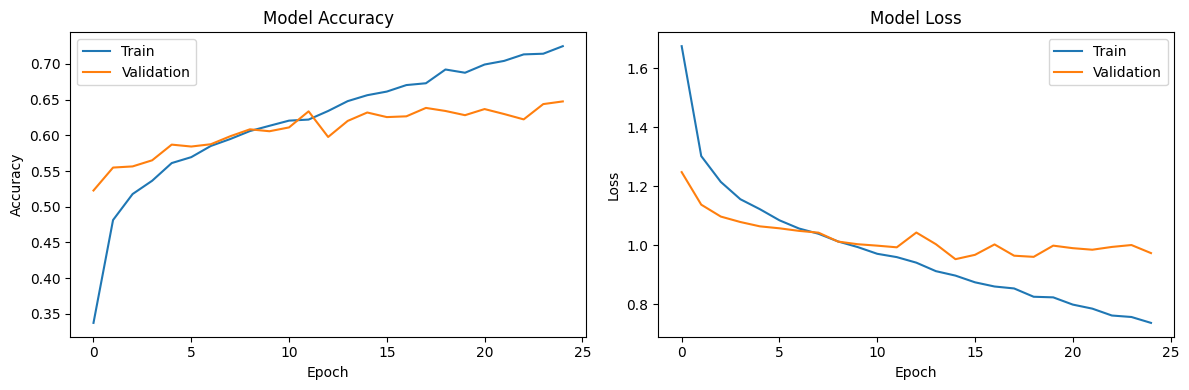


✅ Model saved as 'speech_emotion_model.h5'

🔬 Test Prediction:
   File: D:\Artifical Intelligence\RAVDESS/Actor_01\03-01-01-01-01-01-01.wav
   True Emotion: neutral
   Predicted: calm (Confidence: 0.34)

✅ Speech Emotion Recognition Pipeline Complete!


In [2]:
# ============================================
# EMOTION RECOGNITION — LSTM MODEL
# ============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD METADATA ----------
df = pd.read_csv('speech_emotion_metadata.csv')
print(f"✅ Loaded {len(df)} files")

# ---------- 2. BALANCE DATA (Optional) ----------
# Agar dataset bohat bada hai toh sample le sakte ho
# df = df.sample(n=5000, random_state=42)  # 5000 samples

# ---------- 3. EXTRACT MFCC FEATURES ----------
def extract_mfcc(file_path, n_mfcc=20, max_len=50):
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=2)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        return mfcc.T
    except:
        return None

print("\n🎵 Extracting MFCC features...")
print("⏳ This may take 5-10 minutes...")

X = []
y = []

for idx, row in df.iterrows():
    mfcc = extract_mfcc(row['file_path'])
    if mfcc is not None:
        X.append(mfcc)
        y.append(row['emotion'])

X = np.array(X)
y = np.array(y)

print(f"✅ Extracted features from {len(X)} files")
print(f"✅ Feature shape: {X.shape}")  # (samples, time_steps, n_mfcc)

# ---------- 4. ENCODE LABELS ----------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(f"\n📊 Emotions: {label_encoder.classes_}")
print(f"📊 Number of classes: {len(label_encoder.classes_)}")

# ---------- 5. TRAIN-TEST SPLIT ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📊 Train size: {X_train.shape[0]}")
print(f"📊 Test size: {X_test.shape[0]}")

# ---------- 6. BUILD LSTM MODEL ----------
model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

print("\n🧠 Model Summary:")
model.summary()

# ---------- 7. TRAIN MODEL ----------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ---------- 8. EVALUATE ----------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Speech Emotion Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ---------- 9. PLOT TRAINING HISTORY ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

# ---------- 10. SAVE MODEL ----------
model.save('speech_emotion_model.h5')
print("\n✅ Model saved as 'speech_emotion_model.h5'")

# ---------- 11. PREDICTION FUNCTION ----------
def predict_emotion(file_path, model, label_encoder):
    mfcc = extract_mfcc(file_path)
    if mfcc is None:
        return "Error loading file"
    mfcc = np.expand_dims(mfcc, axis=0)
    pred = model.predict(mfcc, verbose=0)
    emotion = label_encoder.inverse_transform([np.argmax(pred)])[0]
    confidence = np.max(pred)
    return emotion, confidence

# Test prediction on a sample
sample_file = df.iloc[0]['file_path']
sample_emotion = df.iloc[0]['emotion']

pred_emotion, confidence = predict_emotion(sample_file, model, label_encoder)
print(f"\n🔬 Test Prediction:")
print(f"   File: {sample_file}")
print(f"   True Emotion: {sample_emotion}")
print(f"   Predicted: {pred_emotion} (Confidence: {confidence:.2f})")

print("\n✅ Speech Emotion Recognition Pipeline Complete!")

✅ Loaded 11682 files
✅ Using 2000 samples

🎵 Extracting Mel-Spectrograms...
⏳ This may take 5-10 minutes...
   Processed 100 files...
   Processed 200 files...
   Processed 300 files...
   Processed 400 files...
   Processed 500 files...
   Processed 600 files...
   Processed 700 files...
   Processed 800 files...
   Processed 900 files...
   Processed 1000 files...
   Processed 1100 files...
   Processed 1200 files...
   Processed 1300 files...
   Processed 1400 files...
   Processed 1500 files...
   Processed 1600 files...
   Processed 1700 files...
   Processed 1800 files...
   Processed 1900 files...
   Processed 2000 files...
✅ Feature shape: (2000, 128, 128, 1)
📊 Emotions: ['angry' 'calm' 'disgust' 'fear' 'fearful' 'happy' 'neutral' 'sad'
 'surprised' 'unknown']
📊 Train: 1600, Test: 400

🧠 CNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,250 (12.61 MB)

 Trainable params: 3,305,802 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.1512 - loss: 7.8024 - val_accuracy: 0.1625 - val_loss: 2.2782
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 372ms/step - accuracy: 0.1608 - loss: 2.2668 - val_accuracy: 0.1531 - val_loss: 2.2798
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - accuracy: 0.1658 - loss: 2.2459 - val_accuracy: 0.1063 - val_loss: 2.2378
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 337ms/step - accuracy: 0.1758 - loss: 2.2112 - val_accuracy: 0.1000 - val_loss: 2.1830
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 347ms/step - accuracy: 0.1597 - loss: 2.1904 - val_accuracy: 0.1031 - val_loss: 2.1568
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 339ms/step - accuracy: 0.1845 - loss: 2.1695 - val_accuracy: 0.1031 - val_loss: 2.1607
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 342ms/step - accuracy: 0.1707 - loss: 2.1588 - val_accuracy: 0.0969 - val_loss: 2.1518
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 336ms/step - accuracy: 0.1858 - loss: 2.1396 - val_accu

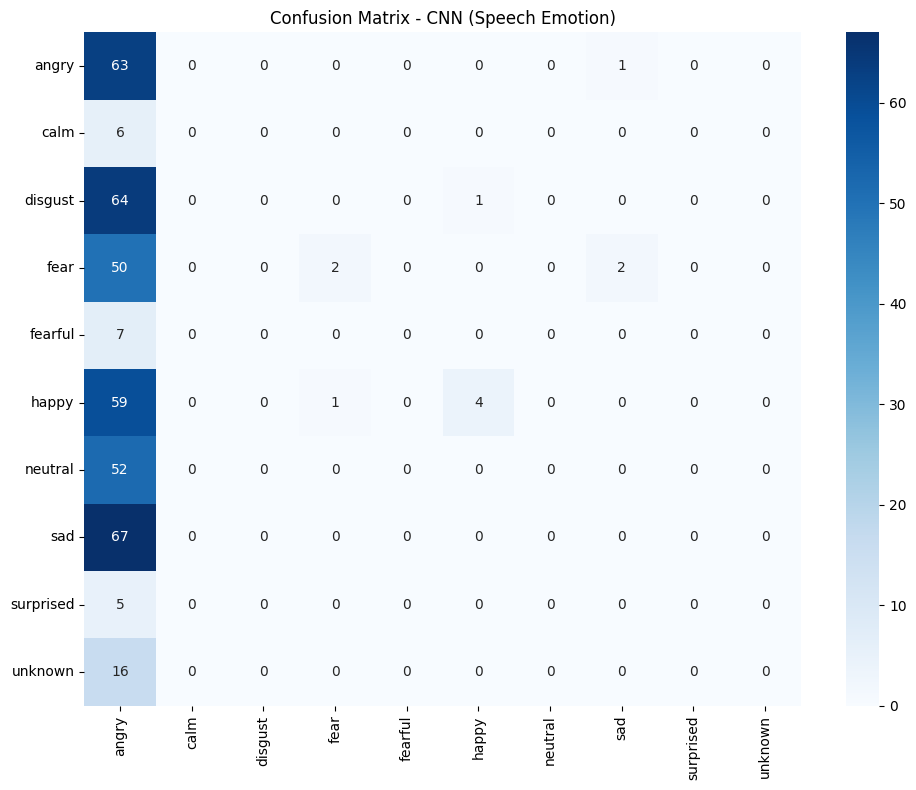


✅ CNN Model saved as 'speech_emotion_cnn.h5'

✅ CNN Model Complete!


In [3]:
# ============================================
# EMOTION RECOGNITION — CNN MODEL
# (Mel-Spectrogram based)
# ============================================

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD METADATA ----------
df = pd.read_csv('speech_emotion_metadata.csv')
print(f"✅ Loaded {len(df)} files")

# Sample data (lighter for laptop)
df_sampled = df.sample(n=2000, random_state=42)
print(f"✅ Using {len(df_sampled)} samples")

# ---------- 2. EXTRACT MEL-SPECTROGRAM ----------
def extract_mel_spectrogram(file_path, n_mels=128, max_len=128):
    """
    Extract Mel-Spectrogram from audio file
    Returns: (max_len, n_mels) — like an image
    """
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=2)
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Pad or truncate
        if mel_spec_db.shape[1] > max_len:
            mel_spec_db = mel_spec_db[:, :max_len]
        else:
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, max_len - mel_spec_db.shape[1])))
        
        return mel_spec_db.T  # (max_len, n_mels)
    except:
        return None

print("\n🎵 Extracting Mel-Spectrograms...")
print("⏳ This may take 5-10 minutes...")

X = []
y = []

for i in range(len(df_sampled)):
    row = df_sampled.iloc[i]
    mel_spec = extract_mel_spectrogram(row['file_path'])
    if mel_spec is not None:
        X.append(mel_spec)
        y.append(row['emotion'])
    
    if (i+1) % 100 == 0:
        print(f"   Processed {i+1} files...")

X = np.array(X)
y = np.array(y)

# Reshape for CNN: (samples, height, width, channels)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
print(f"✅ Feature shape: {X.shape}")

# ---------- 3. ENCODE LABELS ----------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print(f"📊 Emotions: {label_encoder.classes_}")

# ---------- 4. TRAIN-TEST SPLIT ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"📊 Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ---------- 5. BUILD CNN MODEL ----------
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n🧠 CNN Model Summary:")
model.summary()

# ---------- 6. TRAIN ----------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ---------- 7. EVALUATE ----------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ CNN Test Accuracy: {accuracy:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# ---------- 8. CONFUSION MATRIX ----------
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - CNN (Speech Emotion)')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

# ---------- 9. SAVE MODEL ----------
model.save('speech_emotion_cnn.h5')
print("\n✅ CNN Model saved as 'speech_emotion_cnn.h5'")

print("\n✅ CNN Model Complete!")

✅ Using 3000 samples

🎵 Extracting MFCC features...
   Processed 100 files...
   Processed 200 files...
   Processed 300 files...
   Processed 400 files...
   Processed 500 files...
   Processed 600 files...
   Processed 700 files...
   Processed 800 files...
   Processed 900 files...
   Processed 1000 files...
   Processed 1100 files...
   Processed 1200 files...
   Processed 1300 files...
   Processed 1400 files...
   Processed 1500 files...
   Processed 1600 files...
   Processed 1700 files...
   Processed 1800 files...
   Processed 1900 files...
   Processed 2000 files...
   Processed 2100 files...
   Processed 2200 files...
   Processed 2300 files...
   Processed 2400 files...
   Processed 2500 files...
   Processed 2600 files...
   Processed 2700 files...
   Processed 2800 files...
   Processed 2900 files...
   Processed 3000 files...
✅ Feature shape: (3000, 100, 40)
📊 Train: 2400, Test: 600

🧠 CNN + LSTM Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 25, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,034 (379.04 KB)

 Trainable params: 97,034 (379.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.1616 - loss: 2.1835 - val_accuracy: 0.2104 - val_loss: 2.0447
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1905 - loss: 2.0343 - val_accuracy: 0.3083 - val_loss: 1.8198
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2654 - loss: 1.8674 - val_accuracy: 0.3229 - val_loss: 1.7340
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3024 - loss: 1.8064 - val_accuracy: 0.3146 - val_loss: 1.7222
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3321 - loss: 1.7319 - val_accuracy: 0.3417 - val_loss: 1.6619
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3042 - loss: 1.7462 - val_accuracy: 0.3292 - val_loss: 1.6566
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3418 - loss: 1.6801 - val_accuracy: 0.3417 - val_loss: 1.5991
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3687 - loss: 1.6141 - val_accu

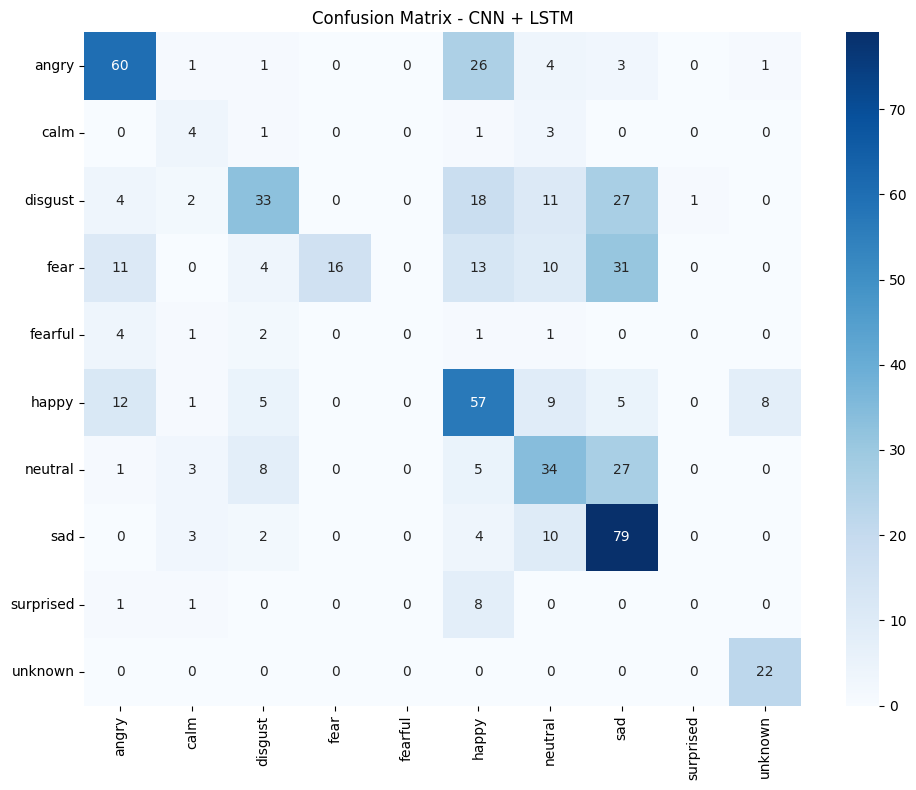


✅ Model saved as 'speech_emotion_cnn_lstm.h5'


In [7]:
# ============================================
# EMOTION RECOGNITION — CNN + LSTM (SIMPLE)
# ============================================

import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout, Reshape, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD DATA ----------
df = pd.read_csv('speech_emotion_metadata.csv')
df_sampled = df.sample(n=3000, random_state=42)
print(f"✅ Using {len(df_sampled)} samples")

# ---------- 2. EXTRACT MFCC ----------
def extract_mfcc(file_path, n_mfcc=40, max_len=100):
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=2)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        return mfcc.T  # (max_len, n_mfcc)
    except:
        return None

print("\n🎵 Extracting MFCC features...")
X = []
y = []

for i in range(len(df_sampled)):
    row = df_sampled.iloc[i]
    mfcc = extract_mfcc(row['file_path'])
    if mfcc is not None:
        X.append(mfcc)
        y.append(row['emotion'])
    if (i+1) % 100 == 0:
        print(f"   Processed {i+1} files...")

X = np.array(X)
y = np.array(y)
print(f"✅ Feature shape: {X.shape}")  # (samples, time_steps, n_mfcc)

# ---------- 3. ENCODE LABELS ----------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# ---------- 4. TRAIN-TEST SPLIT ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"📊 Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ---------- 5. BUILD CNN + LSTM MODEL (SIMPLE) ----------
model = Sequential([
    # CNN part (1D CNN on MFCC features)
    Input(shape=(X.shape[1], X.shape[2])),  # (time_steps, n_mfcc)
    
    # Conv1D layers (treats MFCC features as 1D signals)
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),
    
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),
    
    # LSTM part
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\n🧠 CNN + LSTM Model Summary:")
model.summary()

# ---------- 6. TRAIN ----------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ---------- 7. EVALUATE ----------
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"\n✅ CNN + LSTM Accuracy: {accuracy:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# ---------- 8. CONFUSION MATRIX ----------
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - CNN + LSTM')
plt.tight_layout()
plt.savefig('cnn_lstm_confusion_matrix.png', dpi=150)
plt.show()

# ---------- 9. SAVE MODEL ----------
model.save('speech_emotion_cnn_lstm.h5')
print("\n✅ Model saved as 'speech_emotion_cnn_lstm.h5'")

In [11]:
# ============================================
# REAL-TIME EMOTION DETECTION FROM SPEECH
# Using LSTM Model + Microphone
# ============================================

import numpy as np
import librosa
import sounddevice as sd
import soundfile as sf
import tempfile
import os
import time
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD MODEL & LABELS ----------
model = load_model('speech_emotion_model.h5')

# Load label encoder (you need to save it during training)
# If you don't have it saved, we'll recreate it
emotions = [
    'angry', 'calm', 'disgust', 'fear', 
    'fearful', 'happy', 'neutral', 'sad', 
    'surprised', 'unknown'
]
label_encoder = LabelEncoder()
label_encoder.fit(emotions)

# ---------- 2. EMOTION EMOJI MAPPING ----------
emotion_emojis = {
    'angry': '😡',
    'calm': '😌',
    'disgust': '🤢',
    'fear': '😨',
    'fearful': '😰',
    'happy': '😊',
    'neutral': '😐',
    'sad': '😢',
    'surprised': '😲',
    'unknown': '🤔'
}

emotion_colors = {
    'angry': 'red',
    'calm': 'lightblue',
    'disgust': 'green',
    'fear': 'purple',
    'fearful': 'darkpurple',
    'happy': 'yellow',
    'neutral': 'grey',
    'sad': 'blue',
    'surprised': 'orange',
    'unknown': 'black'
}

# ---------- 3. RECORD AUDIO FUNCTION ----------
def record_audio(duration=3, samplerate=16000):
    """
    Record audio from microphone
    
    Parameters:
    - duration: recording duration in seconds (default: 3)
    - samplerate: sample rate (default: 16000)
    
    Returns:
    - audio_data: numpy array of recorded audio
    """
    print(f"\n🎤 Recording for {duration} seconds...")
    print("🔴 Speak now...")
    
    # Record audio
    audio_data = sd.rec(int(duration * samplerate), 
                        samplerate=samplerate, 
                        channels=1, 
                        dtype='float32')
    sd.wait()  # Wait until recording is finished
    
    print("✅ Recording complete!")
    return audio_data.flatten()

# ---------- 4. EXTRACT MFCC ----------
def extract_mfcc_from_audio(audio, sr=16000, n_mfcc=40, max_len=100):
    """
    Extract MFCC features from audio array
    """
    try:
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        return mfcc.T  # (max_len, n_mfcc)
    except Exception as e:
        print(f"Error extracting MFCC: {e}")
        return None

# ---------- 5. PREDICT EMOTION ----------
def predict_emotion_from_audio(audio, model, label_encoder):
    """
    Predict emotion from audio array
    """
    # Extract MFCC
    mfcc = extract_mfcc_from_audio(audio)
    if mfcc is None:
        return "unknown", 0.0
    
    # Reshape for model input: (1, time_steps, n_mfcc)
    mfcc = np.expand_dims(mfcc, axis=0)
    
    # Predict
    prediction = model.predict(mfcc, verbose=0)
    emotion_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    emotion = label_encoder.inverse_transform([emotion_idx])[0]
    return emotion, confidence

# ---------- 6. DISPLAY RESULT ----------
def display_emotion(emotion, confidence):
    """
    Display emotion with emoji and color
    """
    emoji = emotion_emojis.get(emotion, '❓')
    color = emotion_colors.get(emotion, 'white')
    
    print("\n" + "="*50)
    print("🎯 EMOTION DETECTION RESULT")
    print("="*50)
    print(f"   Emotion: {emoji} {emotion.upper()}")
    print(f"   Confidence: {confidence*100:.1f}%")
    print("="*50)

# ---------- 7. MAIN FUNCTION ----------
def real_time_emotion_detection(duration=3, samplerate=16000):
    """
    Main function for real-time emotion detection
    """
    print("\n" + "="*60)
    print("🎤 REAL-TIME EMOTION DETECTION FROM SPEECH")
    print("="*60)
    print("🔊 Speak clearly into the microphone...")
    print(f"⏱️ Recording duration: {duration} seconds")
    print("="*60)
    
    # Record audio
    audio = record_audio(duration, samplerate)
    
    # Save audio to temp file (optional - for debugging)
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.wav')
    sf.write(temp_file.name, audio, samplerate)
    print(f"📁 Audio saved to: {temp_file.name}")
    
    # Predict emotion
    emotion, confidence = predict_emotion_from_audio(audio, model, label_encoder)
    
    # Display result
    display_emotion(emotion, confidence)
    
    return emotion, confidence, audio

# ---------- 8. CONTINUOUS DETECTION (OPTIONAL) ----------
def continuous_detection(duration=3, samplerate=16000):
    """
    Continuously detect emotion from microphone
    Press Ctrl+C to stop
    """
    print("\n" + "="*60)
    print("🔄 CONTINUOUS EMOTION DETECTION")
    print("="*60)
    print("Press Ctrl+C to stop")
    print("="*60)
    
    try:
        while True:
            emotion, confidence, _ = real_time_emotion_detection(duration, samplerate)
            
            # Ask if user wants to continue
            choice = input("\n🔁 Detect again? (y/n): ").lower()
            if choice != 'y':
                break
                
    except KeyboardInterrupt:
        print("\n👋 Stopped by user.")

# ---------- 9. RUN ----------
if __name__ == "__main__":
    # Install required libraries if not available
    try:
        import sounddevice
    except ImportError:
        print("⚠️ Installing sounddevice...")
        os.system("pip install sounddevice soundfile")
        import sounddevice
    
    # Single detection
    real_time_emotion_detection(duration=3)
    
    # Uncomment below for continuous detection
    # continuous_detection(duration=3)


🎤 REAL-TIME EMOTION DETECTION FROM SPEECH
🔊 Speak clearly into the microphone...
⏱️ Recording duration: 3 seconds

🎤 Recording for 3 seconds...
🔴 Speak now...
✅ Recording complete!
📁 Audio saved to: C:\Users\Prime\AppData\Local\Temp\tmp69qnha4n.wav


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 40 and 20 for '{{node sequential_1/bidirectional_1/forward_lstm_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1/bidirectional_1/forward_lstm_1/strided_slice_1, sequential_1/bidirectional_1/forward_lstm_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [1,40], [20,512].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(1, 40), dtype=float32)
  • states=('tf.Tensor(shape=(1, 128), dtype=float32)', 'tf.Tensor(shape=(1, 128), dtype=float32)')
  • training=False

In [13]:


# ============================================
# REAL-TIME EMOTION DETECTION (DEBUG VERSION)
# ============================================

import numpy as np
import librosa
import sounddevice as sd
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD MODEL ----------
model = load_model('speech_emotion_model.h5')
print(f"✅ Model loaded!")
print(f"✅ Input shape: {model.input_shape}")

# ---------- 2. EMOTIONS ----------
emotions = ['angry', 'calm', 'disgust', 'fear', 'fearful', 'happy', 'neutral', 'sad', 'surprised', 'unknown']

# ---------- 3. RECORD ----------
def record_audio(duration=3, sr=16000):
    print(f"🎤 Recording {duration}s...")
    audio = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='float32')
    sd.wait()
    return audio.flatten()

# ---------- 4. EXTRACT MFCC ----------
def extract_mfcc(audio, sr=16000, n_mfcc=40, max_len=100):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] > max_len:
        mfcc = mfcc[:, :max_len]
    else:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
    return mfcc.T  # (100, 40)

# ---------- 5. PREDICT ----------
def predict_emotion(audio):
    mfcc = extract_mfcc(audio)  # (100, 40)
    mfcc = np.expand_dims(mfcc, axis=0)  # (1, 100, 40)
    
    print(f"📊 Input shape: {mfcc.shape}")
    
    pred = model.predict(mfcc, verbose=0)
    idx = np.argmax(pred)
    conf = np.max(pred)
    return emotions[idx], conf

# ---------- 6. MAIN ----------
print("\n🔊 Speak now...")
audio = record_audio(3)
emotion, conf = predict_emotion(audio)
print(f"\n🎯 Emotion: {emotion.upper()} ({conf*100:.1f}%)")

✅ Model loaded!
✅ Input shape: (None, 50, 20)

🔊 Speak now...
🎤 Recording 3s...
📊 Input shape: (1, 100, 40)


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 40 and 20 for '{{node sequential_1/bidirectional_1/forward_lstm_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_1/bidirectional_1/forward_lstm_1/strided_slice_1, sequential_1/bidirectional_1/forward_lstm_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [1,40], [20,512].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(1, 40), dtype=float32)
  • states=('tf.Tensor(shape=(1, 128), dtype=float32)', 'tf.Tensor(shape=(1, 128), dtype=float32)')
  • training=False

In [14]:
import os
print(os.path.exists('speech_emotion_model.h5'))  # Should be True

True


In [15]:
print(model.input_shape)  # Should be (None, 100, 40)

(None, 50, 20)


In [21]:
# ============================================
# REAL-TIME EMOTION DETECTION (FIXED SHAPE)
# Model: (None, 50, 20)
# ============================================

import numpy as np
import librosa
import sounddevice as sd
import soundfile as sf
import tempfile
import os
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD MODEL ----------
model = load_model('speech_emotion_model.h5')
print(f"✅ Model loaded!")
print(f"✅ Model input shape: {model.input_shape}")  # (None, 50, 20)

# ---------- 2. EMOTIONS ----------
emotions = [
    'angry', 'calm', 'disgust', 'fear', 
    'fearful', 'happy', 'neutral', 'sad', 
    'surprised', 'unknown'
]

emotion_emojis = {
    'angry': '😡',
    'calm': '😌',
    'disgust': '🤢',
    'fear': '😨',
    'fearful': '😰',
    'happy': '😊',
    'neutral': '😐',
    'sad': '😢',
    'surprised': '😲',
    'unknown': '🤔'
}

# ---------- 3. EXTRACT MFCC (MATCHING MODEL) ----------
def extract_mfcc(audio, sr=16000, n_mfcc=20, max_len=50):  # 👈 20 features, 50 time steps
    """
    Extract MFCC features matching model input shape
    """
    try:
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Pad or truncate to fixed length
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        
        return mfcc.T  # (max_len, n_mfcc) -> (50, 20)
    except Exception as e:
        print(f"Error extracting MFCC: {e}")
        return None

# ---------- 4. RECORD AUDIO ----------
def record_audio(duration=3, samplerate=16000):
    print(f"\n🎤 Recording for {duration} seconds...")
    print("🔴 Speak now...")
    
    audio_data = sd.rec(int(duration * samplerate), 
                        samplerate=samplerate, 
                        channels=1, 
                        dtype='float32')
    sd.wait()
    
    print("✅ Recording complete!")
    return audio_data.flatten()

# ---------- 5. PREDICT EMOTION ----------
def predict_emotion(audio):
    mfcc = extract_mfcc(audio)
    if mfcc is None:
        return "unknown", 0.0
    
    # Reshape: (1, 50, 20)
    mfcc = np.expand_dims(mfcc, axis=0)
    
    print(f"📊 Input shape: {mfcc.shape}")  # Should be (1, 50, 20)
    
    # Predict
    prediction = model.predict(mfcc, verbose=0)
    emotion_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    emotion = emotions[emotion_idx]
    return emotion, confidence

# ---------- 6. DISPLAY RESULT ----------
def display_emotion(emotion, confidence):
    emoji = emotion_emojis.get(emotion, '❓')
    
    print("\n" + "="*50)
    print("🎯 EMOTION DETECTION RESULT")
    print("="*50)
    print(f"   Emotion: {emoji} {emotion.upper()}")
    print(f"   Confidence: {confidence*100:.1f}%")
    print("="*50)

# ---------- 7. MAIN FUNCTION ----------
def real_time_emotion_detection(duration=3):
    print("\n" + "="*60)
    print("🎤 REAL-TIME EMOTION DETECTION")
    print("="*60)
    print("🔊 Speak clearly into the microphone...")
    print("="*60)
    
    # Record
    audio = record_audio(duration)
    
    # Predict
    emotion, confidence = predict_emotion(audio)
    
    # Display
    display_emotion(emotion, confidence)
    
    return emotion, confidence

# ---------- 8. RUN ----------
if __name__ == "__main__":
    try:
        import sounddevice
    except ImportError:
        print("⚠️ Installing sounddevice...")
        os.system("pip install sounddevice soundfile")
        import sounddevice
    
    real_time_emotion_detection(duration=3)

✅ Model loaded!
✅ Model input shape: (None, 50, 20)

🎤 REAL-TIME EMOTION DETECTION
🔊 Speak clearly into the microphone...

🎤 Recording for 3 seconds...
🔴 Speak now...
✅ Recording complete!
📊 Input shape: (1, 50, 20)

🎯 EMOTION DETECTION RESULT
   Emotion: 😲 SURPRISED
   Confidence: 38.4%


In [28]:
# ============================================
# REAL-TIME EMOTION DETECTION (IMPROVED)
# ============================================

import numpy as np
import librosa
import sounddevice as sd
from tensorflow.keras.models import load_model
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD MODEL ----------
model = load_model('speech_emotion_model.h5')
print(f"✅ Model loaded!")
print(f"✅ Model input shape: {model.input_shape}")

# ---------- 2. EMOTIONS ----------
emotions = ['angry', 'calm', 'disgust', 'fear', 'fearful', 'happy', 'neutral', 'sad', 'surprised', 'unknown']
emotion_emojis = {
    'angry': '😡', 'calm': '😌', 'disgust': '🤢', 'fear': '😨',
    'fearful': '😰', 'happy': '😊', 'neutral': '😐', 'sad': '😢',
    'surprised': '😲', 'unknown': '🤔'
}

# ---------- 3. EXTRACT MFCC ----------
def extract_mfcc(audio, sr=16000, n_mfcc=20, max_len=50):
    try:
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        return mfcc.T
    except:
        return None

# ---------- 4. RECORD WITH VAD ----------
def record_audio(duration=3, samplerate=16000):
    print(f"\n🎤 Recording {duration}s... Speak clearly!")
    audio = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1, dtype='float32')
    sd.wait()
    audio = audio.flatten()
    
    # Remove silence
    threshold = 0.01
    voice_indices = np.where(np.abs(audio) > threshold)[0]
    if len(voice_indices) > 0:
        audio = audio[voice_indices[0]:voice_indices[-1]]
    
    if len(audio) < 1000:
        print("⚠️ No voice detected! Please speak louder.")
        return None
    
    return audio

# ---------- 5. PREDICT ----------
def predict_emotion(audio, threshold=0.5):
    if audio is None:
        return "unknown", 0.0
    
    mfcc = extract_mfcc(audio)
    if mfcc is None:
        return "unknown", 0.0
    
    mfcc = np.expand_dims(mfcc, axis=0)
    prediction = model.predict(mfcc, verbose=0)
    emotion_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    if confidence < threshold:
        return "unknown", confidence
    
    return emotions[emotion_idx], confidence

# ---------- 6. ENSEMBLE PREDICTION ----------
def ensemble_predict(num_trials=3, duration=2):
    print("\n" + "="*60)
    print("🎤 SPEAK THE SAME EMOTION 3 TIMES")
    print("="*60)
    
    results = []
    confidences = []
    
    for i in range(num_trials):
        print(f"\n🔴 Trial {i+1}/{num_trials}")
        audio = record_audio(duration)
        emotion, conf = predict_emotion(audio, threshold=0.4)
        results.append(emotion)
        confidences.append(conf)
        print(f"   → {emotion_emojis.get(emotion, '❓')} {emotion} ({conf*100:.1f}%)")
    
    # Majority voting
    final_emotion = Counter(results).most_common(1)[0][0]
    avg_confidence = np.mean(confidences)
    
    print("\n" + "="*50)
    print("🎯 FINAL RESULT")
    print("="*50)
    print(f"   Emotion: {emotion_emojis.get(final_emotion, '❓')} {final_emotion.upper()}")
    print(f"   Confidence: {avg_confidence*100:.1f}%")
    print("="*50)
    
    return final_emotion, avg_confidence

# ---------- 7. RUN ----------
if __name__ == "__main__":
    ensemble_predict(num_trials=3, duration=2)

✅ Model loaded!
✅ Model input shape: (None, 50, 20)

🎤 SPEAK THE SAME EMOTION 3 TIMES

🔴 Trial 1/3

🎤 Recording 2s... Speak clearly!
   → 🤔 unknown (34.7%)

🔴 Trial 2/3

🎤 Recording 2s... Speak clearly!
   → 😨 fear (58.8%)

🔴 Trial 3/3

🎤 Recording 2s... Speak clearly!
   → 😨 fear (60.6%)

🎯 FINAL RESULT
   Emotion: 😨 FEAR
   Confidence: 51.4%


✅ Model loaded!
✅ Model input shape: (None, 50, 20)

🎤 SPEECH EMOTION DETECTION
1. Single Recording
2. Ensemble (3 recordings)

🎤 REAL-TIME EMOTION DETECTION
🔊 Speak clearly into the microphone...
⏱️ Recording duration: 3 seconds

🎤 Recording for 3 seconds...
🔴 Speak clearly into the microphone...
✅ Recording complete!
📁 Audio saved to: recording_20260716_231725.wav


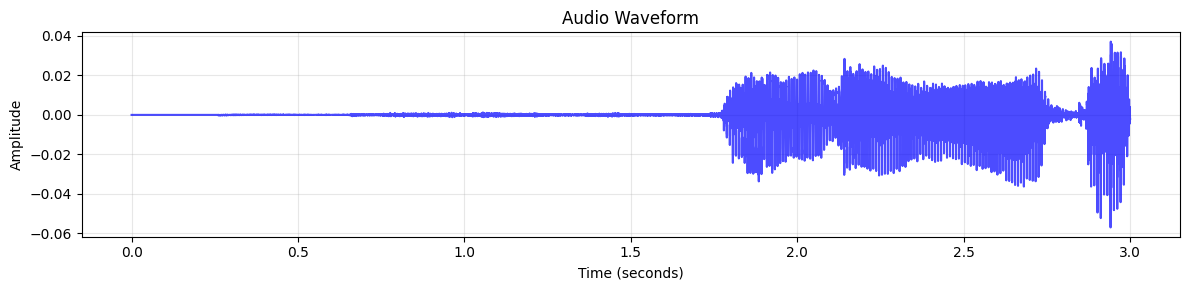

📊 Waveform saved as 'audio_waveform.png'

🔊 Playing back your recording...
🔊 Playing: recording_20260716_231725.wav

🎯 EMOTION DETECTION RESULT
📁 File: recording_20260716_231725.wav
🎭 Emotion: 😌 CALM
📊 Confidence: 48.6%
   Confidence: [██████████████░░░░░░░░░░░░░░░░] 48.6%


In [29]:
# ============================================
# COMPLETE REAL-TIME EMOTION DETECTION
# Record → Save → Playback → Predict
# ============================================

import numpy as np
import librosa
import sounddevice as sd
import soundfile as sf
import os
import time
import matplotlib.pyplot as plt
import IPython.display as ipd
from tensorflow.keras.models import load_model
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. LOAD MODEL ----------
model = load_model('speech_emotion_model.h5')
print(f"✅ Model loaded!")
print(f"✅ Model input shape: {model.input_shape}")

# ---------- 2. EMOTIONS MAPPING ----------
emotions = [
    'angry', 'calm', 'disgust', 'fear', 
    'fearful', 'happy', 'neutral', 'sad', 
    'surprised', 'unknown'
]

emotion_emojis = {
    'angry': '😡',
    'calm': '😌',
    'disgust': '🤢',
    'fear': '😨',
    'fearful': '😰',
    'happy': '😊',
    'neutral': '😐',
    'sad': '😢',
    'surprised': '😲',
    'unknown': '🤔'
}

emotion_colors = {
    'angry': '#FF0000',
    'calm': '#4FC3F7',
    'disgust': '#4CAF50',
    'fear': '#9C27B0',
    'fearful': '#6A1B9A',
    'happy': '#FFD700',
    'neutral': '#9E9E9E',
    'sad': '#2196F3',
    'surprised': '#FF9800',
    'unknown': '#000000'
}

# ---------- 3. RECORD AUDIO ----------
def record_audio(duration=3, samplerate=16000, filename=None):
    """
    Record audio from microphone and save as WAV file
    """
    if filename is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        filename = f"recording_{timestamp}.wav"
    
    print(f"\n🎤 Recording for {duration} seconds...")
    print("🔴 Speak clearly into the microphone...")
    
    # Record
    audio_data = sd.rec(int(duration * samplerate), 
                        samplerate=samplerate, 
                        channels=1, 
                        dtype='float32')
    sd.wait()  # Wait until recording is finished
    
    print("✅ Recording complete!")
    
    # Save audio file
    sf.write(filename, audio_data, samplerate)
    print(f"📁 Audio saved to: {filename}")
    
    return audio_data.flatten(), filename, samplerate

# ---------- 4. PLAYBACK AUDIO ----------
def play_audio(filename):
    """
    Play the recorded audio file
    """
    try:
        print(f"🔊 Playing: {filename}")
        return ipd.Audio(filename, autoplay=True)
    except Exception as e:
        print(f"⚠️ Playback error: {e}")
        print("💡 You can manually play the file using any audio player.")
        return None

# ---------- 5. EXTRACT MFCC ----------
def extract_mfcc(audio, sr=16000, n_mfcc=20, max_len=50):
    try:
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] > max_len:
            mfcc = mfcc[:, :max_len]
        else:
            mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
        return mfcc.T
    except Exception as e:
        print(f"Error extracting MFCC: {e}")
        return None

# ---------- 6. PREDICT EMOTION ----------
def predict_emotion(audio, threshold=0.3):
    if audio is None:
        return "unknown", 0.0
    
    mfcc = extract_mfcc(audio)
    if mfcc is None:
        return "unknown", 0.0
    
    mfcc = np.expand_dims(mfcc, axis=0)
    prediction = model.predict(mfcc, verbose=0)
    emotion_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    if confidence < threshold:
        return "unknown", confidence
    
    return emotions[emotion_idx], confidence

# ---------- 7. VISUALIZE AUDIO ----------
def visualize_audio(audio, sr=16000):
    """
    Plot audio waveform
    """
    plt.figure(figsize=(12, 3))
    time_axis = np.linspace(0, len(audio)/sr, len(audio))
    plt.plot(time_axis, audio, color='blue', alpha=0.7)
    plt.title('Audio Waveform')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('audio_waveform.png', dpi=150)
    plt.show()
    print("📊 Waveform saved as 'audio_waveform.png'")

# ---------- 8. DISPLAY RESULT ----------
def display_result(emotion, confidence, filename):
    emoji = emotion_emojis.get(emotion, '❓')
    color = emotion_colors.get(emotion, '#000000')
    
    print("\n" + "="*60)
    print("🎯 EMOTION DETECTION RESULT")
    print("="*60)
    print(f"📁 File: {filename}")
    print(f"🎭 Emotion: {emoji} {emotion.upper()}")
    print(f"📊 Confidence: {confidence*100:.1f}%")
    print("="*60)
    
    # Confidence bar
    bar_length = int(confidence * 30)
    bar = '█' * bar_length + '░' * (30 - bar_length)
    print(f"   Confidence: [{bar}] {confidence*100:.1f}%")
    print("="*60)

# ---------- 9. MAIN FUNCTION ----------
def real_time_emotion_detection(duration=3):
    """
    Complete pipeline: Record → Save → Playback → Predict
    """
    print("\n" + "="*60)
    print("🎤 REAL-TIME EMOTION DETECTION")
    print("="*60)
    print("🔊 Speak clearly into the microphone...")
    print(f"⏱️ Recording duration: {duration} seconds")
    print("="*60)
    
    # Step 1: Record
    audio, filename, sr = record_audio(duration)
    
    # Step 2: Visualize
    visualize_audio(audio, sr)
    
    # Step 3: Playback (optional)
    print("\n🔊 Playing back your recording...")
    play_audio(filename)
    
    # Step 4: Predict
    emotion, confidence = predict_emotion(audio)
    
    # Step 5: Display result
    display_result(emotion, confidence, filename)
    
    return emotion, confidence, filename

# ---------- 10. ENSEMBLE PREDICTION (3 tries) ----------
def ensemble_emotion_detection(num_trials=3, duration=2):
    """
    Record multiple times and use majority voting
    """
    print("\n" + "="*60)
    print("🎤 ENSEMBLE EMOTION DETECTION")
    print("="*60)
    print(f"🔊 Speak the same emotion {num_trials} times")
    print("="*60)
    
    results = []
    confidences = []
    filenames = []
    
    for i in range(num_trials):
        print(f"\n🔴 Trial {i+1}/{num_trials}")
        emotion, conf, filename = real_time_emotion_detection(duration)
        results.append(emotion)
        confidences.append(conf)
        filenames.append(filename)
        
        # Small pause between recordings
        if i < num_trials - 1:
            print("\n⏳ Get ready for next recording...")
            time.sleep(1)
    
    # Majority voting
    from collections import Counter
    final_emotion = Counter(results).most_common(1)[0][0]
    avg_confidence = np.mean(confidences)
    
    print("\n" + "="*60)
    print("🎯 FINAL ENSEMBLE RESULT")
    print("="*60)
    print(f"📊 Individual results: {results}")
    print(f"🎭 Final Emotion: {emotion_emojis.get(final_emotion, '❓')} {final_emotion.upper()}")
    print(f"📊 Average Confidence: {avg_confidence*100:.1f}%")
    print("="*60)
    
    return final_emotion, avg_confidence

# ---------- 11. RUN ----------
if __name__ == "__main__":
    try:
        import sounddevice
    except ImportError:
        print("⚠️ Installing required libraries...")
        os.system("pip install sounddevice soundfile")
        import sounddevice
    
    # Choose mode
    print("\n" + "="*60)
    print("🎤 SPEECH EMOTION DETECTION")
    print("="*60)
    print("1. Single Recording")
    print("2. Ensemble (3 recordings)")
    print("="*60)
    
    choice = input("Enter your choice (1 or 2): ").strip()
    
    if choice == '2':
        ensemble_emotion_detection(num_trials=3, duration=2)
    else:
        real_time_emotion_detection(duration=3)